# 一、基础操作：打开与关闭文件
1. 核心函数：open()
    - open()用于打开文件，返回一个文件对象。
2. file_obj = open(file_path, mode='r', encoding=None, buffering=-1, ...)
    - file_path：文件路径（相对路径或绝对路径）。
    - mode：文件打开模式（如只读、写入、追加等），默认 'r'（只读文本模式）。
    - encoding：文本模式下的编码格式（如 'utf-8'），二进制模式无需指定。
3. 推荐方式：with语句（自动关闭文件）
    - 使用with语句可自动管理文件资源，即使发生异常也能安全关闭文件，避免资源泄漏。

In [1]:
# 示例：用 with 打开并读取文件
with open("../0-文件/test.txt", "r", encoding="utf-8") as f:
    content = f.read()
    print(content)
# 离开 with 块后，文件自动关闭，无需手动调用 f.close()

这是一个测试文件-test.txt


4. 手动关闭（不推荐，除非特殊场景）：若不使用with，需手动调用close()关闭文件。

In [2]:
f = open("../0-文件/test.txt", "r", encoding="utf-8")
try:
    content = f.read()
    print(content)
finally:
    f.close()  # 确保文件被关闭

这是一个测试文件-test.txt


# 二、文件打开模式
1. mode参数由基础模式和可选修饰符组成，常见组合如下：
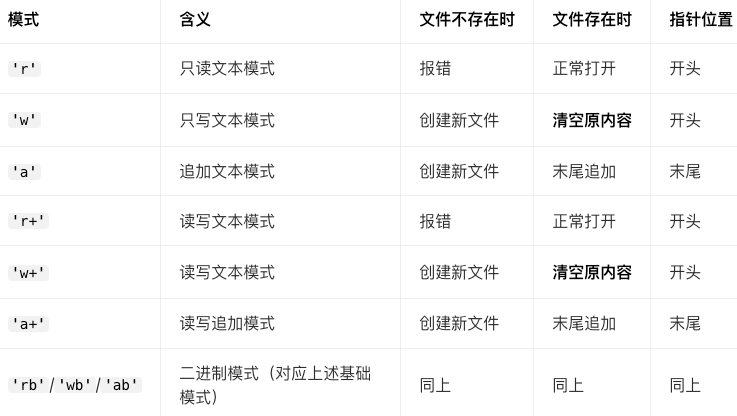
2. 关键区别：
    - 'w' vs 'a'：'w' 会清空原文件，'a' 仅在末尾追加。
    - 'r+' vs 'w+'：'r+' 不清空原文件，'w+' 会清空。
    - 文本模式 vs 二进制模式：文本模式处理字符串（自动处理换行符），二进制模式处理字节（如图片、视频、exe 文件）。

# 三、文件读写操作
1. 读取文件（文本模式）
- 方法1:read(size==-1)-读取全部内容
    - size：可选，指定读取的字符数（文本模式）或字节数（二进制模式），默认-1读取全部。

In [5]:
with open("../0-文件/test.txt", "r", encoding="utf-8") as f:
    content = f.read()  # 读取整个文件
    print(content)

第一行：这是一个测试文件-test.txt \n
第二行：人生苦短，我用Python


- 方法2:readline(size==-1)-逐行读取
    - 每次读取一行，包含换行符\n；返回空字符串时表示到达文件末尾。

In [4]:
with open("../0-文件/test.txt", "r", encoding="utf-8") as f:
    while True:
        line = f.readline()
        if not line:  # 空字符串表示结束
            break
        print(line.strip())  # strip() 去除首尾空白（包括换行符）

第一行：这是一个测试文件-test.txt \n
第二行：人生苦短，我用Python


- 方法3:readlines(hint==-1)-读取所有行到列表
    - 返回列表，每个元素是文件的一行（包含换行符）

In [7]:
with open("../0-文件/test.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()  # 列表：["第一行\n", "第二行\n", ...]
    for line in lines:
        print(line.strip())
    print(lines)

第一行：这是一个测试文件-test.txt \n
第二行：人生苦短，我用Python
['第一行：这是一个测试文件-test.txt \\n\n', '第二行：人生苦短，我用Python']


2. 写入文件（文本模式）
- 方式1:write(s)-写入字符串
    - 返回写入的字符数（文本模式）或字节数（二进制模式）。
    - 注意：不会自动添加换行符，需手动添加“\n”。

In [10]:
print("第一次写入前：")
with open("../0-文件/write.txt", "r", encoding="utf-8") as f:
    content = f.read()  # 读取整个文件
    print(content)

# 写入模式：清空原文件后写入
with open("../0-文件/write.txt", "w", encoding="utf-8") as f:
    f.write("第一行内容\n")
    f.write("第二行内容\n")

print("第一次写入后：")
with open("../0-文件/write.txt", "r", encoding="utf-8") as f:
    content = f.read()  # 读取整个文件
    print(content)

# 追加模式：在末尾添加
with open("../0-文件/write.txt", "a", encoding="utf-8") as f:
    f.write("第三行内容（追加）\n")

print("第二次写入后：")
with open("../0-文件/write.txt", "r", encoding="utf-8") as f:
    content = f.read()  # 读取整个文件
    print(content)

第一次写入前：
第一行内容
第二行内容
第三行内容（追加）

第一次写入后：
第一行内容
第二行内容

第二次写入后：
第一行内容
第二行内容
第三行内容（追加）



- 方法2:writelines(lines) - 写入字符串列表
    - 接收可迭代对象（如列表、元组），每个元素是一行；同样不会自动添加换行符。

In [12]:
lines = ["第一行\n", "第二行\n", "第三行\n"]
try:
    with open("../0-文件/output.txt", "w", encoding="utf-8") as f:
        f.writelines(lines)
except Exception as e:
    raise e

3. 二进制文件读写（图片、视频）。
- 使用'rb'(读二进制)和'wb'(写二进制)模式，处理字节数据。

In [14]:
# 复制图片（二进制读写示例）
with open("../0-文件/ollama.png", "rb") as f_in:
    content = f_in.read()  # 读取全部字节

with open("../0-文件/ollamaCopy.png", "wb") as f_out:
    f_out.write(content)  # 写入字节

# 四、文件指针操作
文件指针用于标记当前读写位置，可通过seek()和tell()控制。
1. tell()：获取当前指针位置。返回指针距离文件开头的字节数（二进制模式）或字符数（文本模式）。

In [20]:
with open("../0-文件/test.txt", "r", encoding="utf-8") as f:
    print(f.tell())  # 初始位置：0
    f.read(5)        # 读取 5 个字符
    print(f.tell())  # 指针位置：15

0
15


2. seek(offset,whence=0)：移动指针
    - whence：参考位置（仅二进制模式支持全部选项）：
        - 0:从文件开头（默认）
        - 1:从当前位置
        - 2:从文件末尾
    - offset：便宜量（正数向后，负数向前）

In [23]:
"""
english.txt->
This is an apple.
I can tell you about the...
"""
# 二进制模式下的指针操作示例
with open("../0-文件/english.txt", "rb") as f:
    f.seek(5)          # 从开头移动 5 字节
    print(f.read(3))   # 读取第 5-7 字节
    f.seek(-2, 1)      # 从当前位置向前移动 2 字节
    print(f.read(2))   # 重新读取
    f.seek(-3, 2)      # 从末尾向前移动 3 字节
    print(f.read())    # 读取最后 3 字节

b'is '
b's '
b'...'


# 五、其他文件操作（借助os模块）

In [24]:
import os

1. 文件重命名

In [25]:
os.rename("../0-文件/old_name.txt", "../0-文件/new_name.txt")

2. 删除文件
- os.remove("to_delete.txt")

3. 检查文件是否存在

In [26]:
if os.path.exists("test.txt"):
    print("文件存在")
else:
    print("文件不存在")

文件不存在


4. 创建/删除目录
    - os.mkdir("new_dir")       # 创建单级目录
    - os.makedirs("a/b/c")      # 创建多级目录（递归）
    - os.rmdir("empty_dir")     # 删除空目录
    - os.removedirs("a/b/c")    # 递归删除空目录

# 六、常见错误
1. 忘记关闭文件
    - 错误示例：不用with，也不手动close()，导致资源泄漏

In [27]:
f = open("../0-文件/test.txt", "r")
content = f.read()  # 读完后文件未关闭

In [28]:
# 记得关闭
f.close()

2. 模式使用错误
    - 错误1:用只读模式 'r' 写入文件，报错 io.UnsupportedOperation。

In [29]:
with open("../0-文件/test.txt", "r") as f:
    f.write("hello")  # 报错：不支持写入

UnsupportedOperation: not writable

- 错误2:用 'w' 模式打开已存在文件，导致原内容被清空。
    - 解决：根据需求选择模式，修改文件优先用 'r+' 或 'a'，避免误操作 'w'。

3. 编码问题
    - 错误示例：Windows 下默认编码为 gbk，读取 utf-8 编码的文件时乱码或报错。

In [30]:
with open("../0-文件/test.txt", "r") as f:  # 未指定 encoding，Windows 下默认 gbk
    content = f.read()  # 若文件是 utf-8，可能报错 UnicodeDecodeError

4. 路径问题
    - 错误1:相对路径错误
    - 错误2:路径使用反斜杠\，未转义导致错误
5. 大文件读取用read()导致内存溢出
    - 错误示例：读取几个 G 的日志文件，直接用 read() 会占满内存。
        - 解决：逐行迭代（内存占用最小），或分块读取。
6. writelines() 不自动加换行符
    - 错误示例：写入列表时忘记加 \n，导致所有内容连在一起。

In [31]:
lines = ["第一行", "第二行", "第三行"]
with open("../0-文件/output.txt", "w", encoding="utf-8") as f:
    f.writelines(lines)  # 结果："第一行第二行第三行"